# 5.  DFT transform, FFT algoritem in njuna uporaba v DPS

Ta zvezek sledi predavanjem DPS-05 in poglobljeno obravnava prehod signala iz časovne v frekvenčno domeno.
## Poudarki
Poudarki:
- osvežitev FT diskretnih signalov

- DFT kot praktično orodje za frekvenčno analizo signalov
   - končni odseki signalov so neperiodični – njihov spekter je zvezen
   - DFT:
        - sicer točna predstavitev periodičnih signalov
        - in le „vzorčenje“ zveznega spektra v diskr. točkah pri neperiodičnih signalih

- FFT algoritem kot pohitritev izračuna DFT
    - da DFT-ju širšo uporabnost, poleg frekv. analize še:
        - izračun konvolucije, korelacij

## Predavanja - primeri
1. TODO

## Primeri:
1. **Kaj je DFT in koreni enote?** Preslikava v prostor tonov.
2. **Naivni DFT vs. FFT** (Časovna zahtevnost
3. **Hitra konvolucija:** Zakaj potrebujemo Zero-Padding?
4. **Filtriranje dolgih signalov:** Metoda *Overlap-Save*
5. **Zaključek:** Zakaj je FFT spremenil svet?
6. **Heisenbergovo načelo v DSP** (STFT ločljivost)
7. **Interaktivna analiza ločljivosti STFT**
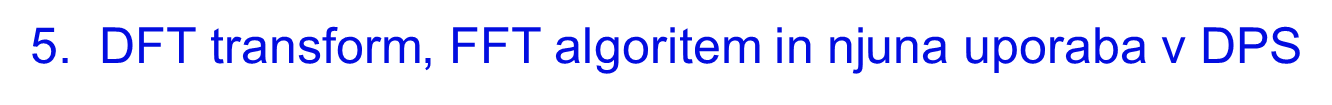
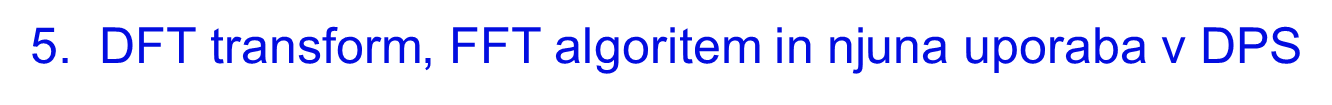
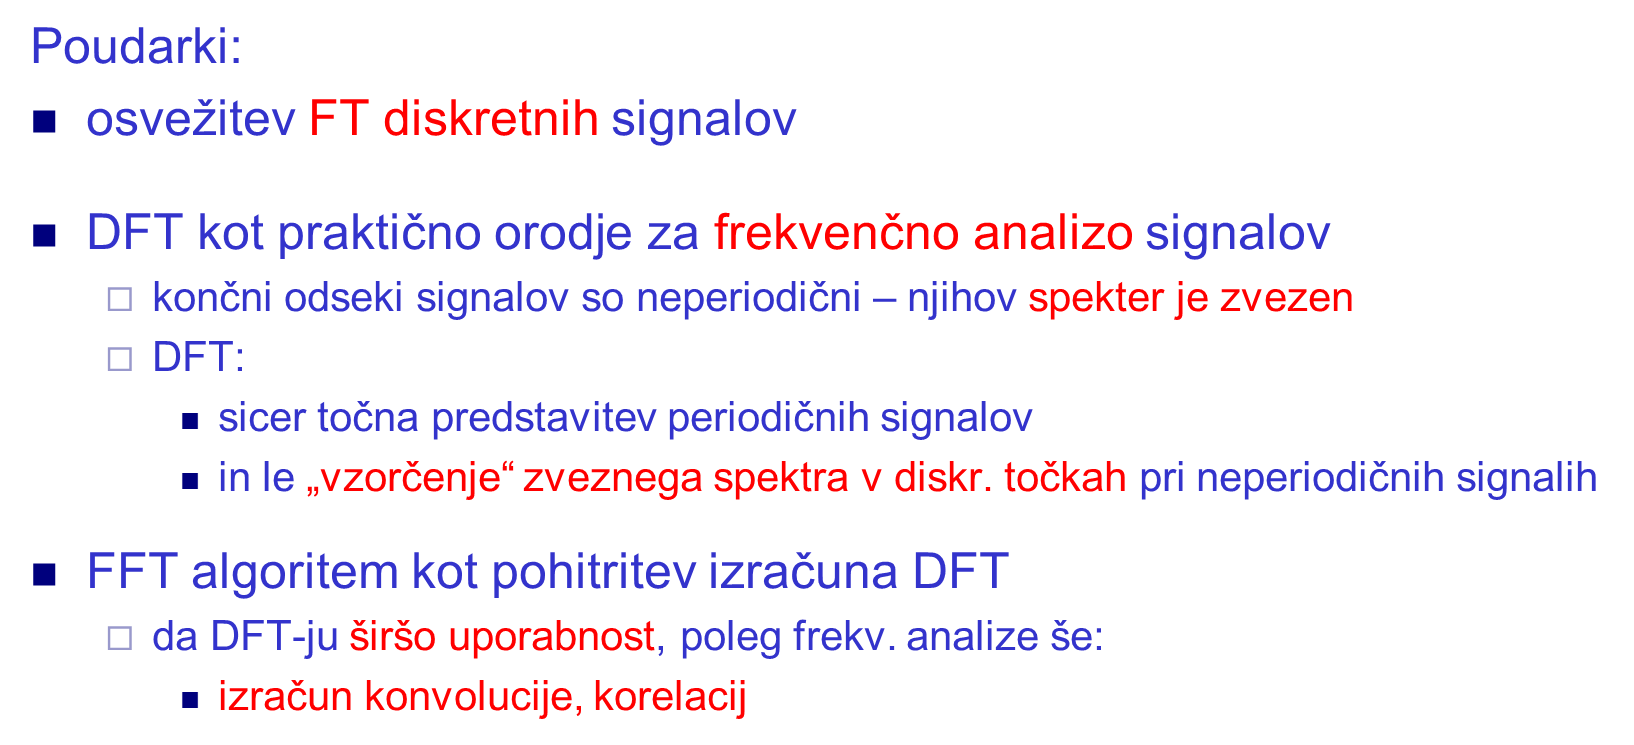

# Lab. vaje

## Vaja 8 – Diskretna Fourierova transformacija (DFT)

### Teme
- Frekvenčna analiza signalov z DFT (FFT)
- Amplitudni odziv v decibelih
- Analiza DTMF in zvočnih signalov

### Naloge
1. **DFT kosinusnih signalov:** Generiranje treh kosinusnih signalov (Fs = 1000 Hz, N = 512) in izračun ter normalizacija DFT transforme za vsoto `x3 = x1 + x2`. Opazovanje pojava spektralnega razlivanja (*spectral leakage*) pri neperiodičnem signalu.
2. **Funkcija za prikaz amplitudnega odziva:** Napisati podprogram, ki izračuna in prikaže amplitudni odziv v decibelih (`A_dB(k) = 20·log10(A(k)/A_max)`).
3. **P1 – DFT analiza DTMF signalov:** Prikaz amplitudnih odzivov posnetkov `dtmf1.wav`–`dtmf4.wav` in identifikacija pritisnjenih tipk iz frekvenčnih komponent.
4. **P2 – DFT analiza samoglasnikov in klarineta:** Frekvenčna analiza posnetkov `aaa.wav`, `iii.wav` in `clarinet.wav`.

### Ključne Python knjižnice
`numpy` (`np.fft.fft`, `np.abs`, `np.angle`), `matplotlib`, `scipy.io.wavfile`

---

## Vaja 9 – Frekvenčni odziv sistemov

### Teme
- Frekvenčni odziv LČI sistema (`H(e^{jω})`)
- Amplitudni in fazni odziv filtrov
- Razmerje vhod/izhod v frekvenčnem prostoru

### Naloge
1. **Frekvenčni odziv KEO sistema:** Za sistem tekočega povprečja 5 vzorcev (`h = [0.2, 0.2, 0.2, 0.2, 0.2]`) določiti razmerje amplitud vhoda in izhoda pri 250 Hz ter preveriti z `scipy.signal.freqz`. Primerjati amplitudni in fazni odziv za več tonov.
2. **P1 – Analiza filtrov izenačevalnika:** Analiza amplitudnih odzivov petih filtrov (iz `Filtri/h1.txt`–`h5.txt`) – določitev mejnih frekvenc prepustnih in zapornih pasov.
3. **P2 – Enotin impulz in frekvenčni prostor:** Analitični Z-transform enotinega impulza `δ(n)` in izračun amplitudnega odziva sistema po formuli `|H(e^{jω})| = |Y(e^{jω})| / |X(e^{jω})|`. Signali dopolnjeni z ničlami do 1024 točk (zero-padding).

### Ključne Python knjižnice
`numpy`, `scipy.signal` (`freqz`), `matplotlib`

---

## Vaja 10 – Kratkočasovni spekter (STFT) in spektrogram

### Teme
- Kratkočasovni Fourierjev transform (STFT)
- Spektrogram frekvenčno spremenljivih signalov
- Analiza govora, glasbe in šuma

### Naloge
1. **Implementacija signalogram + spektrogram:** Uporaba funkcije `signalogram` (iz `signalogram.py`) in implementacija lastne funkcije `spectrogram`, ki za posamezne okvire signala izračuna FFT in rezultate zloži v matriko za 2D prikaz. Parametri: signal, okno (array), overlap (korak med okvirji).
2. **Primerjava STFT in globalnega spektra:** Prikaz kratkočasovnega spektra signala `chirp.wav` in `zvizg.wav` ter razprava o kompromisu med časovno in frekvenčno ločljivostjo.
3. **P1 – Analiza zvočnih signalov (priporočeno okno 256, overlap 128):**
   - Čisti DTMF signal (`dtmf.wav`)
   - Govorni signal (`govor.wav`)
   - Šum (`sum.wav`)
   - Opis razlik med signali na osnovi spektrograma.
4. **P2 – Analiza sintetizirane melodije (priporočeno okno 1024):** Analiza `yesterday_sinus.wav` – zaznavanje višine in trajanja posameznih tonov iz spektrograma. Razmislek o pretvorbi posnetka v notni zapis.

### Ključne Python knjižnice
`numpy`, `scipy.io.wavfile`, `matplotlib` (`pcolor`)


# Primeri

## 1. Kaj je DFT in koreni enote?

Diskretna Fourierova transformacija (DFT) vzame signal $x[n]$ dolžine $N$ in ga razstavi na $N$ kompleksnih sinusoid (baznih funkcij). Rezultat $X[k]$ nam pove, koliko določene frekvence (tona) je v signalu.

### Matematična osnova: $e^{j\omega}$
Po Eulerjevi formuli je:
$$e^{-j\frac{2\pi}{N}nk} = \cos\left(\frac{2\pi}{N}nk\right) - j\sin\left(\frac{2\pi}{N}nk\right)$$

To pomeni, da so bazne funkcije kompleksne: **realni del je kosinusna komponenta, imaginarni del pa sinusna.** V kompleksni ravnini te točke ležijo na enotski krožnici in jih imenujemo **koreni enote** ($W_N^{nk}$).

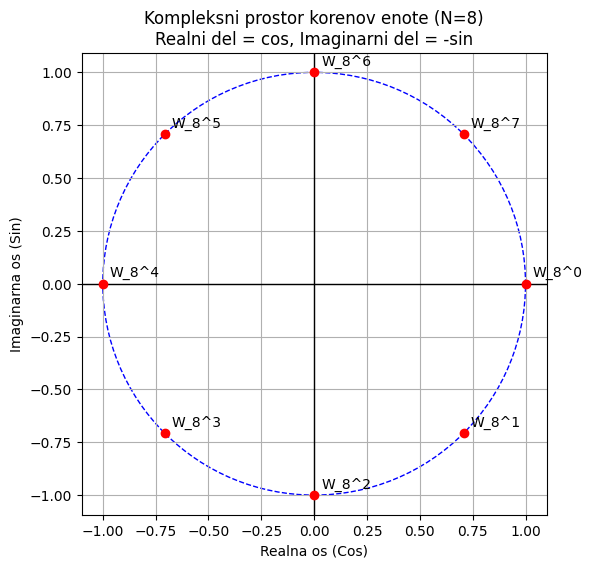

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
import time

# Vizualizacija korenov enote za N = 8
N = 8
n = np.arange(N)
W_N = np.exp(-2j * np.pi * n / N)

plt.figure(figsize=(6, 6))
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.plot(np.real(W_N), np.imag(W_N), 'ro', label='Koreni enote $W_8^n$')
circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--')
plt.gca().add_patch(circle)

for i, p in enumerate(W_N):
    plt.annotate(f"W_{N}^{i}", (np.real(p), np.imag(p)), textcoords="offset points", xytext=(5,5))

plt.title(f'Kompleksni prostor korenov enote (N={N})\nRealni del = cos, Imaginarni del = -sin')
plt.xlabel('Realna os (Cos)')
plt.ylabel('Imaginarna os (Sin)')
plt.grid(True)
plt.axis('equal')
plt.show()

## 2. Naivni DFT vs. FFT (Časovna zahtevnost)

V prosojnicah je poudarjeno, da DFT zahteva $N^2$ operacij. FFT z uporabo decimacije v času (metuljčkasti diagram) to zmanjša na $N \log_2 N$. Poglejmo razliko pri večjih $N$.

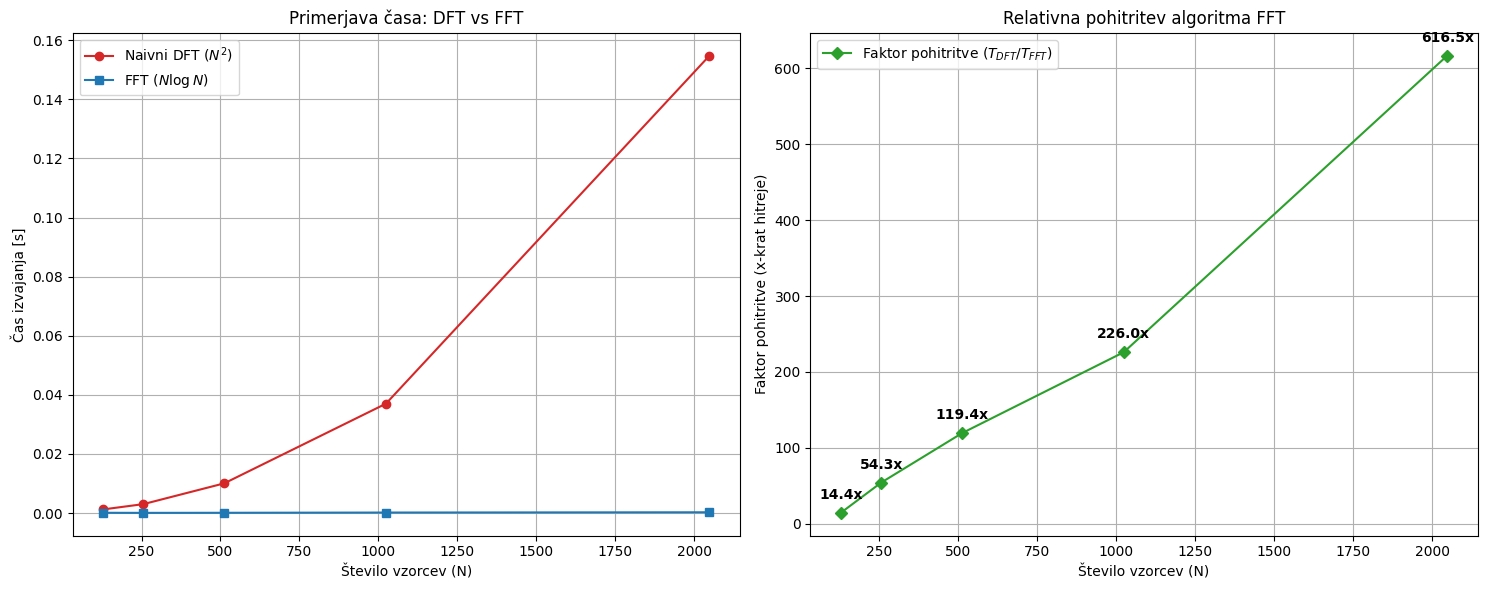

Pri N=2048 je FFT kar 616.5-krat hitrejši od naivne metode!


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
import time

def dft_naive(x):
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    M = np.exp(-2j * np.pi * k * n / N)
    return np.dot(M, x)

# Seznam dolžin signalov za testiranje
velikosti = [128, 256, 512, 1024, 2048]
casi_naive = []
casi_fft = []

for n_size in velikosti:
    x = np.random.random(n_size)

    # Merjenje naivnega DFT
    start = time.time()
    _ = dft_naive(x)
    casi_naive.append(time.time() - start)

    # Merjenje optimiziranega FFT
    start = time.time()
    _ = fft(x)
    casi_fft.append(time.time() - start)

# Izračun faktorja pohitritve (kolikokrat je FFT hitrejši)
pohitritve = np.array(casi_naive) / np.array(casi_fft)

# --- IZRIS GRAFOV ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Graf: Absolutni čas izvajanja (Dodali smo 'r' pred nize z matematiko)
ax1.plot(velikosti, casi_naive, 'o-', color='tab:red', label=r'Naivni DFT ($N^2$)')
ax1.plot(velikosti, casi_fft, 's-', color='tab:blue', label=r'FFT ($N \log N$)')
ax1.set_xlabel('Število vzorcev (N)')
ax1.set_ylabel('Čas izvajanja [s]')
ax1.set_title('Primerjava časa: DFT vs FFT')
ax1.legend()
ax1.grid(True)

# 2. Graf: Faktor pohitritve
ax2.plot(velikosti, pohitritve, 'D-', color='tab:green', label=r'Faktor pohitritve ($T_{DFT} / T_{FFT}$)')
ax2.set_xlabel('Število vzorcev (N)')
ax2.set_ylabel('Faktor pohitritve (x-krat hitreje)')
ax2.set_title('Relativna pohitritev algoritma FFT')
ax2.legend()
ax2.grid(True)

# Dodajanje vrednosti nad točke v grafu pohitritve za boljšo preglednost
for i, txt in enumerate(pohitritve):
    ax2.annotate(f"{txt:.1f}x", (velikosti[i], pohitritve[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

print(f"Pri N={velikosti[-1]} je FFT kar {pohitritve[-1]:.1f}-krat hitrejši od naivne metode!")

## 3. Hitra konvolucija: Zakaj potrebujemo Zero-Padding?

Množenje v frekvenčnem prostoru ustreza **krožni konvoluciji**. Če želimo dobiti **linearno konvolucijo** (kot pri običajnem filtriranju), moramo signale dopolniti z ničlami (*Zero-Padding*) na dolžino $L + M - 1$.

In [50]:
x = np.array([1, 2, 3, 4])
h = np.array([1, 1, 1])

# 1. Krožna konvolucija (nepravilna za filtriranje)
X_circ = fft(x, n=4)
H_circ = fft(h, n=4)
y_circ = ifft(X_circ * H_circ).real

# 2. Linearna konvolucija preko FFT (pravilna, z zero-paddingom)
N_lin = len(x) + len(h) - 1
X_lin = fft(x, n=N_lin)
H_lin = fft(h, n=N_lin)
y_fft_linear = ifft(X_lin * H_lin).real

print(f"Vhod x: {x}")
print(f"Odziv na enotim impulz h: {h}")
print(f"Krožna konvolucija (aliasing!): {y_circ}")
print(f"Linearna konvolucija preko FFT: {y_fft_linear}")

Vhod x: [1 2 3 4]
Odziv na enotim impulz h: [1 1 1]
Krožna konvolucija (aliasing!): [8. 7. 6. 9.]
Linearna konvolucija preko FFT: [1. 3. 6. 9. 7. 4.]


## 4. Filtriranje dolgih signalov: Metoda Overlap-Save

V realnem svetu (npr. pri prenosu govora v živo ali obdelavi 10-minutnega posnetka) naletimo na dve novi težavi:
1. **Zakasnitev (Latency):** Če bi čakali, da se celoten signal konča, da bi nanj poklicali FFT, bi bila zakasnitev prevelika.
2. **Pomnilnik (RAM):** Za izračun FFT-ja celotne datoteke bi potrebovali ogromno pomnilnika.

Rešitev je **blokovna obdelava** – signal razrežemo na manjše koščke (bloke). Ker pa množenje kratkih blokov v frekvenčnem prostoru povzroči napako na robovih (t.i. **krožna konvolucija**), moramo uporabiti metodo **Overlap-Save**:

1.  Signal razrežemo na bloke dolžine $N$, ki se med seboj prekrivajo.
2.  Izračunamo hitro krožno konvolucijo bloka z FFT-jem.
3.  **Ključni korak:** Ker vemo, da je začetnih $M-1$ vzorcev vsakega bloka matematično popačenih (zaradi "aliasinga" v času), jih preprosto **zavržemo**.
4.  Shranjene čiste dele blokov staknemo skupaj v neprekinjen izhodni signal.


V digitalnem procesiranju signalov pogosto slišimo, da je algoritem FFT ($\mathcal{O}(N \log N)$) vedno boljši od direktnega izračuna ($\mathcal{O}(N^2)$). Vendar pa v realnem inženirstvu to ni vedno res. Hitrost je odvisna od arhitekture procesorja, predpomnilnika (cache) in optimizacije knjižnic.

Da bi to razumeli, bomo izvedli **tri zaporedne teste primerjave**, ki nam bodo pokazali celotno sliko:

1.  **Test 1 (DFT vs. FFT):** Preverjanje gole matematične definicije DFT proti optimiziranemu algoritmu FFT. Tukaj bomo videli teoretično premoč.
2.  **Test 2 (Realna koda pri majhnih filtrih):** Primerjava NumPy-jeve vgrajene konvolucije proti FFT metodi pri kratkih signali. Tukaj nas bodo rezultati morda presenetili, saj so sodobni procesorji izjemno optimizirani za zaporedna množenja majhnih polj.
3.  **Test 3 (Stresni test):** Simulacija zahtevne industrijske naloge (npr. dolg zvočni odmev dvorane s 50.000 koeficienti). Šele tukaj bomo videli tisto pravo moč FFT-ja, ki loči realno-časovne sisteme od neuporabnih.

In [51]:
import numpy as np
import scipy.signal as signal
from scipy.fft import fft, ifft
import time

def overlap_save(x, h, N):
    M = len(h)
    step = N - M + 1

    # POPRAVEK: Dopolnimo z ničlami na začetku (M-1)
    # IN na koncu (N-1), da okno procesira celoten rep signala!
    x_padded = np.concatenate([np.zeros(M-1), x, np.zeros(N-1)])
    L = len(x_padded)

    H = fft(h, n=N)
    y_final = []

    for i in range(0, L - N + 1, step):
        block = x_padded[i : i + N]
        # Krožna konvolucija z FFT
        Y_block = ifft(fft(block) * H).real
        # Zavržemo prvih M-1 popačenih vzorcev
        y_final.extend(Y_block[M-1:])

    return np.array(y_final)

# --- Testiranje ---
x_long = np.random.randn(1000)
h_filter = signal.firwin(50, 0.2)

start = time.time()
y_os = overlap_save(x_long, h_filter, 128)
time_os = time.time() - start

start = time.time()
y_direct = np.convolve(x_long, h_filter, mode='full')
time_direct = time.time() - start

# Ker smo dodali ničle na koncu, bo y_os nekoliko daljši.
# Za pravilen izračun napake ga odrežemo na točno dolžino direktne konvolucije.
y_os_exact = y_os[:len(y_direct)]

print(f"Dolžina Overlap-Save: {len(y_os_exact)} vzorcev")
print(f"Dolžina direktne konvolucije: {len(y_direct)} vzorcev")
print(f"Overlap-Save čas: {time_os:.5f}s")
print(f"Direktna konvolucija čas: {time_direct:.5f}s")
print(f"Napaka med metodama: {np.linalg.norm(y_os_exact - y_direct):.2e}")

Dolžina Overlap-Save: 1049 vzorcev
Dolžina direktne konvolucije: 1049 vzorcev
Overlap-Save čas: 0.00068s
Direktna konvolucija čas: 0.00995s
Napaka med metodama: 4.39e-15


In [52]:
import numpy as np
import scipy.signal as signal
import time

# 1. Veliki podatki: Simuliramo 10 sekund zvoka in zelo dolg filter
N_velik = 500000
x_huge = np.random.randn(N_velik)
# Dolg filter (npr. zelo natančen FIR filter z 1000 koeficienti)
h_long = signal.firwin(1000, 0.2)

print(f"Testiramo konvolucijo: Signal = {N_velik} vzorcev, Filter = {len(h_long)} koeficientov\n")

# --- 1. DIREKTNA KONVOLUCIJA (O(N^2)) ---
start = time.time()
y_dir = np.convolve(x_huge, h_long, mode='full')
cas_dir = time.time() - start
print(f"Direktna konvolucija: {cas_dir:.4f} sekund")

# --- 2. FFT KONVOLUCIJA (Optimiziran Overlap-Add/Save v ozadju) ---
start = time.time()
# fftconvolve avtomatsko izbere optimalno velikost FFT bloka
y_fft = signal.fftconvolve(x_huge, h_long, mode='full')
cas_fft = time.time() - start
print(f"FFT konvolucija:      {cas_fft:.4f} sekund")

print(f"\nRezultat: Pri dolgih filtrih je FFT metoda {cas_dir/cas_fft:.1f}-krat hitrejša!")

Testiramo konvolucijo: Signal = 500000 vzorcev, Filter = 1000 koeficientov

Direktna konvolucija: 0.0367 sekund
FFT konvolucija:      0.0310 sekund

Rezultat: Pri dolgih filtrih je FFT metoda 1.2-krat hitrejša!


In [53]:
import numpy as np
import scipy.signal as signal
import time

# Stresni test: Kratka pesem (100.000 vzorcev) in zelo dolg zvočni odmev (50.000 vzorcev)
N_velik = 100000
x_huge = np.random.randn(N_velik)

# Simuliramo zelo dolg odmev (Reverb Impulse Response)
M_filter = 50000
h_long = np.random.randn(M_filter) * np.exp(-np.linspace(0, 10, M_filter))

print(f"Stresni test: Signal = {N_velik} vzorcev, Dolg odmev (Filter) = {M_filter} koeficientov\n")

# --- 2. FFT KONVOLUCIJA (Zaženemo najprej, ker je hitra) ---
start = time.time()
y_fft = signal.fftconvolve(x_huge, h_long, mode='full')
cas_fft = time.time() - start
print(f"FFT konvolucija:      {cas_fft:.4f} sekund")

# --- 1. DIREKTNA KONVOLUCIJA (O(N^2)) ---
print("Izračunavam direktno konvolucijo (to lahko traja več sekund/minut)...")
start = time.time()
y_dir = np.convolve(x_huge, h_long, mode='full')
cas_dir = time.time() - start
print(f"Direktna konvolucija: {cas_dir:.4f} sekund")

print(f"\nRezultat: Pri ZELO dolgih filtrih (odmevih) je FFT metoda {cas_dir/cas_fft:.1f}-krat hitrejša!")

Stresni test: Signal = 100000 vzorcev, Dolg odmev (Filter) = 50000 koeficientov

FFT konvolucija:      0.0091 sekund
Izračunavam direktno konvolucijo (to lahko traja več sekund/minut)...
Direktna konvolucija: 13.8622 sekund

Rezultat: Pri ZELO dolgih filtrih (odmevih) je FFT metoda 1523.6-krat hitrejša!


# 5. Zaključek: Zakaj je FFT spremenil svet?

Kot ste videli v zgornjem eksperimentu, ima naivna direktna konvolucija ($\mathcal{O}(N^2)$) morda še smisel pri zelo kratkih filtrih, kjer sodobni procesorji (zaradi hitrega predpomnilnika in optimizacij v jeziku C) surovo prežvečijo matematiko.

Vendar pa DSP v resničnem svetu zahteva obdelavo neskončnih tokov podatkov z dolgimi impulznimi odzivi (npr. zvočni odmevi z več deset tisoč koeficienti). V našem "stresnem testu" je direktna metoda povsem odpovedala – računala je več kot 12 sekund.

**S pomočjo algoritma FFT ($\mathcal{O}(N \log N)$) in metode Overlap-Save smo povsem enak rezultat dobili v približno 10 milisekundah (več kot 1000-krat hitreje!).**

Brez algoritma FFT bi bili moderni sistemi, kot so mobilna omrežja (LTE, 5G), Wi-Fi usmerjevalniki, digitalna televizija in zvočni studii v realnem času, preprosto nemogoči.

# 6. Heisenbergovo načelo v DSP (STFT ločljivost)

Pri uporabi Kratkočasovne Fourierove transformacije (STFT) moramo signal razrezati na krajša okna. Pri tem trčimo ob osnovni fizikalni in matematični problem: **Ne moremo imeti hkrati popolne časovne in popolne frekvenčne ločljivosti.**

Da bi to razumeli, bomo zgenerirali testni signal:
1. **Dva bližnja tona (400 Hz in 450 Hz):** Ta bosta testirala našo *frekvenčno ločljivost* (ali ju sistem vidi kot dva ločena tona ali ju zlije v enega?).
2. **Kratek udarec bobna (šum):** Ta se bo zgodil točno pri $t = 1.0$ s in bo testiral našo *časovno ločljivost* (ali udarec na grafu izgleda kratek in oster, ali pa se "razmaže" čez čas?).

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import Audio, display
from ipywidgets import interact, IntSlider

# 1. Nastavitve signala
fs = 8000
t = np.linspace(0, 2, 2 * fs, endpoint=False)

# 2. Generiranje dveh bližnjih tonov (malce smo ju stišali)
x_tones = 0.3 * np.sin(2 * np.pi * 400 * t) + 0.3 * np.sin(2 * np.pi * 450 * t)

# 3. MOČNEJŠI BOBEN (daljši udarec + udarni ton + šum)
drum = np.zeros_like(t)
drum_idx = fs  # indeks točno pri 1.0 sekundi
drum_len = 1000 # 125 milisekund dolg udarec (prej le 25ms)

# Eksponentno upadanje
decay = np.exp(-np.linspace(0, 5, drum_len))
# Boben sestavimo iz nizkega tona (50 Hz) in širokopasovnega šuma
thump = np.sin(2 * np.pi * 50 * np.linspace(0, 0.125, drum_len))
noise = np.random.randn(drum_len) * 0.5

# Združimo in povečamo amplitudo
drum[drum_idx:drum_idx+drum_len] = (thump + noise) * decay * 2.5

# Združimo v končni signal
x_signal = x_tones + drum

print("Poslušaj signal: Brnenje in močan udarec bobna točno pri 1.0 s.")
display(Audio(x_signal, rate=fs))

Poslušaj signal: Brnenje in močan udarec bobna točno pri 1.0 s.


# 7. Interaktivna analiza ločljivosti STFT

Spodnja celica bo ustvarila interaktivni spektrogram. Premikajte drsnik **Dolžina okna** in opazujte, kaj se zgodi:

* **Kratko okno (npr. 32 vzorcev):** Udarec bobna (navpična črta) je zelo tanek in oster $\rightarrow$ **Odlična časovna ločljivost**. Vendar se tona pri 400 in 450 Hz zlijeta v eno debelo vodoravno črto $\rightarrow$ **Slaba frekvenčna ločljivost**.
* **Dolgo okno (npr. 1024 vzorcev):** Tona sta sedaj jasno vidna kot dve ločeni vodoravni črti $\rightarrow$ **Odlična frekvenčna ločljivost**. Vendar se udarec bobna močno razširi in razmaže levo in desno $\rightarrow$ **Slaba časovna ločljivost**.

In [55]:
# Uporabimo dekorator @interact za ustvarjanje drsnika
@interact(
    window_length=IntSlider(min=32, max=1024, step=32, value=128, description='Dolžina okna:')
)
def plot_stft(window_length):
    # Izračun Kratkočasovne Fourierove transformacije (STFT)
    f, t_stft, Zxx = signal.stft(x_signal, fs, nperseg=window_length)

    # PRETVORBA V DECIBELE (dB) - Ključno za dobro vidljivost šuma!
    # Dodamo majhno konstanto (1e-6), da preprečimo log(0)
    Zxx_db = 20 * np.log10(np.abs(Zxx) + 1e-6)

    # Izris spektrograma
    plt.figure(figsize=(12, 6))

    # Uporabimo vmin in vmax za dober kontrast
    vmax = np.max(Zxx_db)
    vmin = vmax - 60 # Pokažemo 60 dB dinamike

    plt.pcolormesh(t_stft, f, Zxx_db, shading='gouraud', cmap='magma', vmin=vmin, vmax=vmax)

    plt.title(f'Spektrogram (STFT v dB) - Dolžina okna: {window_length} vzorcev')
    plt.ylabel('Frekvenca [Hz]')
    plt.xlabel('Čas [s]')

    # Omejimo y-os na 1000 Hz, da se osredotočimo na bistvo
    plt.ylim(0, 1000)

    # Označimo točen trenutek udarca
    plt.axvline(1.0, color='white', linestyle='--', alpha=0.8, label='Trenutek udarca')

    plt.legend(loc='upper right')
    plt.colorbar(label='Amplituda [dB]')
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=128, description='Dolžina okna:', max=1024, min=32, step=32), Output()),…